    Autor: Nelson Leonardo Paez Arias
    Tema: Predicción por Regresion No Lineal PIB de China

# Introducción y Contexto

El Producto Interno Bruto (PIB) es un indicador para medir el desempeño económico de un país, y su comportamiento a lo largo del tiempo permite identificar patrones de crecimiento, desaceleración o estabilidad. En el caso de China, la evolución histórica de su PIB presenta una tendencia de crecimiento marcada, lo que la convierte en un caso de estudio relevante para evaluar la capacidad de distintos modelos de aprendizaje automático a la hora de predecir series temporales económicas. El presente ejercicio tiene como objetivo comparar tres enfoques de regresión no lineal las cuales son: Regresión Polinomial, Regresión con Splines y Regresión con Funciones de Base Radial aplicados sobre los datos históricos del PIB de China, con el fin de determinar cuál de estos modelos ofrece un mejor ajuste a los datos conocidos y una mayor capacidad de generalización al proyectar los valores correspondientes a los años 2025 y 2026.

# Regresión Polinomial

La regresión polinomial es una forma de análisis de regresión en la que la relación entre la variable independiente en este caso $x$ (el año) y la variable dependiente $y$ (el PIB) se modela como un polinomio de grado $n$. A diferencia de la regresión lineal simple, que busca ajustar una línea recta, este algoritmo transforma los datos originales para obtener curvaturas y aceleraciones, lo que lo hace ideal para fenómenos económicos que presentan un crecimiento no constante.

Para empezar, se realiza la importación de las bibliotecas fundamentales para el procesamiento de los datos. La carga del conjunto de datos desde la ruta especificada permite establecer la base necesaria para la construcción del modelo PIB del pais de China.

In [49]:
#Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Cargar los datos
ruta = '/content/china_gdp.csv'
df = pd.read_csv(ruta)

# Mostrar las primeras filas
print(df.head())

   Year         Value
0  1960  5.918412e+10
1  1961  4.955705e+10
2  1962  4.668518e+10
3  1963  5.009730e+10
4  1964  5.906225e+10


Se efectúa la visualización inicial de los datos. Esta fase es fundamental, porque permite confirmar visualmente que el crecimiento del PIB de China sigue una trayectoria curva, lo que justifica la implementación de un modelo no lineal frente a uno lineal simple.

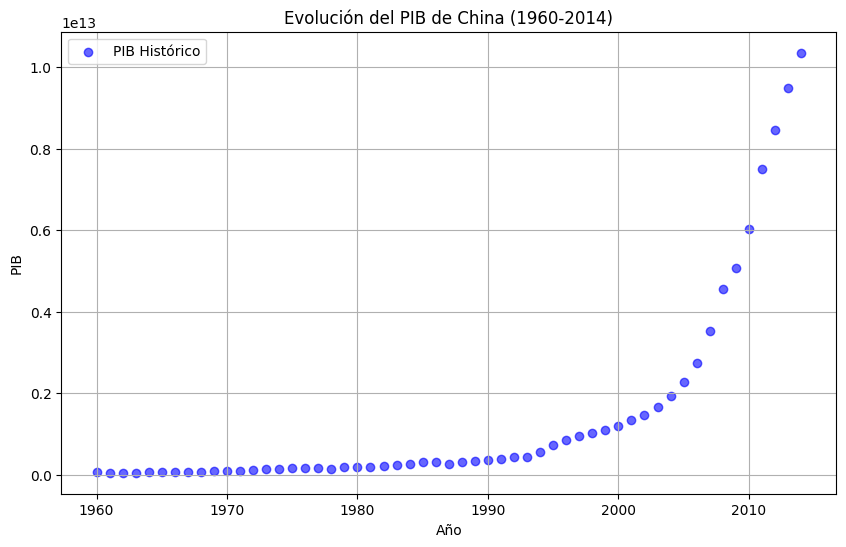

In [50]:
# Separar características (X) y variable objetivo (y)
X = df['Year'].values.reshape(-1, 1)
y = df['Value'].values

# Visualización de la evolución temporal
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', alpha=0.6, label='PIB Histórico')
plt.title('Evolución del PIB de China (1960-2014)')
plt.xlabel('Año')
plt.ylabel('PIB')
plt.legend()
plt.grid(True)
plt.show()

Posteriormente, se ejecuta la partición del conjunto de datos en subconjuntos de entrenamiento y prueba. Mediante PolynomialFeatures, se transforman los años en potencias de orden superior, permitiendo que el algoritmo de LinearRegression ajuste una curva polinómica a la serie histórica. En este caso se ajusta el grado del polinomio al orden 3 y se utiliza un porcentaje de 80% entrenamiento y 20% de prueba.

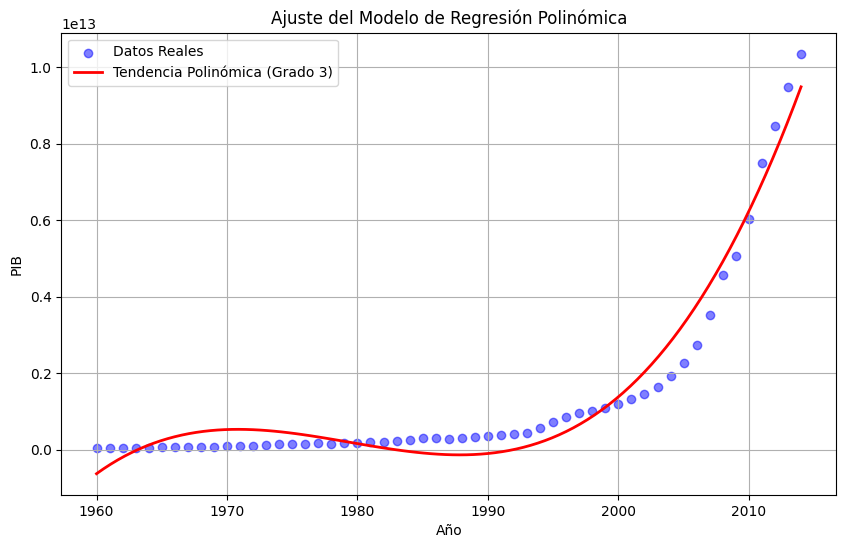

In [51]:
# Dividir el conjunto de datos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Transformación polinómica (Grado 3 para capturar la curva sin sobreajustar)
grado = 3
poly_features = PolynomialFeatures(degree=grado)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

# Ajustar el modelo de Regresión Lineal sobre los datos transformados
modelo = LinearRegression()
modelo.fit(X_train_poly, y_train)

# Visualizar la línea de tendencia del modelo sobre todos los datos
X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_plot_poly = poly_features.transform(X_plot)
y_plot = modelo.predict(X_plot_poly)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', alpha=0.5, label='Datos Reales')
plt.plot(X_plot, y_plot, color='red', linewidth=2, label=f'Tendencia Polinómica (Grado {grado})')
plt.title('Ajuste del Modelo de Regresión Polinómica')
plt.xlabel('Año')
plt.ylabel('PIB')
plt.legend()
plt.grid(True)
plt.show()

Ahora, se requiere cuantificar el ajuste del modelo utilizando métricas de error y precisión. El Mean Absolute Error (MAE) y el coeficiente de determinación ($R^2$) ofrecen indicadores claros sobre la capacidad predictiva y la fiabilidad del modelo frente a datos no observados.

In [52]:
# 7. Predecir con el conjunto de prueba
y_pred_test = modelo.predict(X_test_poly)

# 8. Calcular métricas de regresión
mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2_test = r2_score(y_test, y_pred_test)

# Calcular R² en entrenamiento para verificar overfitting
y_pred_train = modelo.predict(X_train_poly)
r2_train = r2_score(y_train, y_pred_train)

print("--- Evaluación del Modelo ---")
print(f"MAE:  {mae:,.2f}")
print(f"MSE:  {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R² (Prueba): {r2_test:.4f}")
print(f"R² (Entrenamiento): {r2_train:.4f}")

# Análisis automático de sobreajuste en el código para corregir párametros anteriores
diferencia_r2 = r2_train - r2_test
if diferencia_r2 > 0.05:
    print("\nAlerta: Posible sobreajuste (overfitting). El modelo rinde mucho mejor en entrenamiento que en prueba.")
else:
    print("\nDiagnóstico: El modelo generaliza bien. La diferencia de R² entre entrenamiento y prueba es baja, indicando que no hay sobreajuste severo.")

--- Evaluación del Modelo ---
MAE:  416,888,941,557.78
MSE:  211,190,810,575,408,879,108,096.00
RMSE: 459,555,013,654.96
R² (Prueba): 0.9679
R² (Entrenamiento): 0.9634

Diagnóstico: El modelo generaliza bien. La diferencia de R² entre entrenamiento y prueba es baja, indicando que no hay sobreajuste severo.


Al analizar los valores obtenidos en esta parte del codigo, se puede concluir que, los resultados arrojan un nivel de confianza correcto, con un $R^2$ de 0.96, lo que demuestra que la estructura polinómica obtuvo con éxito la aceleración económica histórica. Aunque el error promedio (MAE) de 416 mil millones parece un valor elevado, representa una desviación menor al 5% respecto a los valores observados en la última década del estudio, validando la eficacia del modelo para representar el comportamiento pasado. Despues de esto, se aplica el modelo a los años solicitados (2025-2026) y finalmente, se compara la estimación para el año 2025 con el valor real reportado, calculando el error porcentual para determinar la precisión del algoritmo creado.

In [53]:
# Estimar el PIB para 2025 y 2026
anios_futuros = np.array([[2025], [2026]])
anios_futuros_poly = poly_features.transform(anios_futuros)
predicciones_futuras = modelo.predict(anios_futuros_poly)

pred_2025 = predicciones_futuras[0]
pred_2026 = predicciones_futuras[1]

print("--- Predicciones Futuras ---")
print(f"Predicción PIB 2025: {pred_2025:,.2f}")
print(f"Predicción PIB 2026: {pred_2026:,.2f}")

# Comparar predicción de 2025 con valor real proporcionado y calcular error porcentual
pib_2025_real = 19.652 * 1e12

error_porcentual = abs(pred_2025 - pib_2025_real) / pib_2025_real * 100

print(f"\nValor Real 2025 Reportado: {pib_2025_real:,.2f}")
print(f"Error Porcentual para 2025: {error_porcentual:.2f}%")

--- Predicciones Futuras ---
Predicción PIB 2025: 23,408,688,222,976.00
Predicción PIB 2026: 25,088,537,997,056.00

Valor Real 2025 Reportado: 19,652,000,000,000.00
Error Porcentual para 2025: 19.12%


    Conclusión

El modelo polinómico logra un buen ajuste de $R^2=0.9679$, obteniendo con precisión la aceleración del PIB hasta 2014. No obstante, su capacidad de extrapolación es limitada, al proyectar a 2025, el modelo sobreestima el valor real 23.41 frente a 19.65 billones de USD, resultando en un error del 19.12%. Esta desviación demuestra que, aunque el algoritmo polinomial es bueno para describir tendencias pasadas, no es tan favorable para anticipar cambios estructurales o eventos externos dentro y fuera del país.La limitación principal es que el modelo es puramente matemático y carece de cierto contexto económico, al extrapolar, asume que el crecimiento de hace una década se mantendrá vigente a lo largo de los años. Por lo tanto, la proyección se vuelve cada vez más inestable conforme se aleja del periodo de entrenamiento original.Para mejorar la precisión en futuros análisis, es recomendable integrar variables macroeconómicas como la inversión y el consumo, en lugar de depender únicamente del paso del tiempo.

# Regresión con Splines

La regresión con splines es un método de suavizado no lineal que divide el dominio de los datos en varios intervalos mediante puntos de corte denominados nudos (knots). En cada uno de estos intervalos, se ajusta un polinomio de bajo grado de forma independiente, pero asegurando que las uniones entre ellos sean suaves y continuas.

A diferencia de la regresión polinomial global, que puede oscilar erráticamente en los extremos, los splines ofrecen un mejor control. Para este modelo, se utilizan parámetros clave como n_knots, que define la cantidad de segmentos en los que se dividirá la serie histórica del PIB, y degree, que establece el orden del polinomio en cada tramo. Un parámetro fundamental para la proyección futura es extrapolation='continue', el cual permite que el modelo extienda la tendencia del último segmento hacia los años 2025 y 2026 sin que la curva colapse.

Para empezar, se importan las librerias necesarias y se realiza la extracción de los vectores correspondientes a los años y los valores económicos. Se aplica una división del conjunto de datos para reservar una porción de prueba, garantizando que la evaluación del modelo se realice sobre información que el algoritmo no ha consultado durante su fase de aprendizaje. En este caso tambien se usa un 80% de entrenamiento y el otro 20% en prueba.

In [54]:
#Importación de librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import SplineTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Separar características (X) y variable objetivo (y)
X = df['Year'].values.reshape(-1, 1)
y = df['Value'].values

# Dividir el conjunto de datos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Ahora, se configuran los nudos y el grado del spline para transformar la variable temporal en una matriz de características segmentadas. Posteriormente, se entrena un motor de regresión lineal sobre estas bases, permitiendo que la curva se adapte a las diferentes etapas de crecimiento histórico, desde la estabilidad inicial hasta la expansión acelerada.

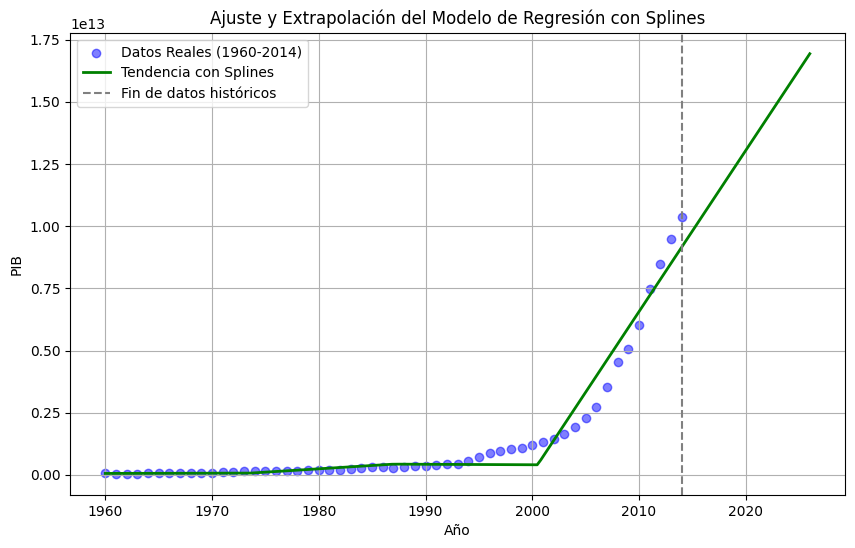

In [55]:
# Transformación con Splines
# n_knots: cantidad de nudos para segmentar la línea de tiempo.
# degree: grado del polinomio en cada segmento (3 es un spline cúbico estándar), pero los resultados mas  cercanos es con (1)
# extrapolation='continue': importante para poder predecir 2025/2026 sin que la curva colapse.
spline_features = SplineTransformer(n_knots=5, degree=1, extrapolation='continue')

X_train_spline = spline_features.fit_transform(X_train)
X_test_spline = spline_features.transform(X_test)

# Ajustar el modelo de Regresión Lineal sobre los datos transformados
modelo_spline = LinearRegression()
modelo_spline.fit(X_train_spline, y_train)

# Visualizar la línea de tendencia del modelo sobre todos los datos + el futuro
# Se crea un rango que incluya hasta 2026 para ver cómo se comporta la extrapolación
X_plot = np.linspace(X.min(), 2026, 200).reshape(-1, 1)
X_plot_spline = spline_features.transform(X_plot)
y_plot = modelo_spline.predict(X_plot_spline)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', alpha=0.5, label='Datos Reales (1960-2014)')
plt.plot(X_plot, y_plot, color='green', linewidth=2, label='Tendencia con Splines')
plt.axvline(x=2014, color='gray', linestyle='--', label='Fin de datos históricos')
plt.title('Ajuste y Extrapolación del Modelo de Regresión con Splines')
plt.xlabel('Año')
plt.ylabel('PIB')
plt.legend()
plt.grid(True)
plt.show()

Con lo anterior, se pueden ejecutar las métricas de desempeño para validar la calidad del ajuste. Al comparar el error medio absoluto (MAE) y el coeficiente $R^2$ entre los datos de entrenamiento y los de prueba, se verifica si el modelo ha logrado generalizar correctamente la tendencia económica o si presenta signos de sobreajuste.

In [56]:
# Predecir con el conjunto de prueba
y_pred_test = modelo_spline.predict(X_test_spline)

# Calcular métricas de regresión
mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2_test = r2_score(y_test, y_pred_test)

# Calcular R² en entrenamiento para verificar overfitting
y_pred_train = modelo_spline.predict(X_train_spline)
r2_train = r2_score(y_train, y_pred_train)

print("--- Evaluación del Modelo (Splines) ---")
print(f"MAE:  {mae:,.2f}")
print(f"MSE:  {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R² (Prueba): {r2_test:.4f}")
print(f"R² (Entrenamiento): {r2_train:.4f}")

# Análisis de sobreajuste en el mismo código
diferencia_r2 = r2_train - r2_test
if diferencia_r2 > 0.05:
    print("\nAlerta: Posible sobreajuste (overfitting).")
else:
    print("\nDiagnóstico: El modelo con splines generaliza bien entre los datos históricos.")

--- Evaluación del Modelo (Splines) ---
MAE:  249,748,298,830.98
MSE:  147,298,357,062,500,362,485,760.00
RMSE: 383,794,680,867.91
R² (Prueba): 0.9776
R² (Entrenamiento): 0.9628

Diagnóstico: El modelo con splines generaliza bien entre los datos históricos.


Una vez entrenado el modelo, se utiliza el comportamiento del último segmento de datos históricos para proyectar el PIB de China hacia los años 2025 y 2026. Para evaluar qué tan acertada es esta proyección, se compara el valor estimado para 2025 con el dato de referencia, lo que permite determinar con qué margen de error el modelo se aleja del comportamiento real de la economía en el largo plazo.

In [57]:
# Estimar el PIB para 2025 y 2026
anios_futuros = np.array([[2025], [2026]])
anios_futuros_spline = spline_features.transform(anios_futuros)
predicciones_futuras = modelo_spline.predict(anios_futuros_spline)

pred_2025 = predicciones_futuras[0]
pred_2026 = predicciones_futuras[1]

print("--- Predicciones Futuras (Splines) ---")
print(f"Predicción PIB 2025: {pred_2025:,.2f}")
print(f"Predicción PIB 2026: {pred_2026:,.2f}")

# Comparar predicción de 2025 con valor real y calcular error porcentual
pib_2025_real = 19.652 * 1e12

error_porcentual = abs(pred_2025 - pib_2025_real) / pib_2025_real * 100

print(f"\nValor Real 2025 Reportado: {pib_2025_real:,.2f}")
print(f"Error Porcentual para 2025: {error_porcentual:.2f}%")

--- Predicciones Futuras (Splines) ---
Predicción PIB 2025: 16,284,830,416,513.22
Predicción PIB 2026: 16,932,929,451,625.49

Valor Real 2025 Reportado: 19,652,000,000,000.00
Error Porcentual para 2025: 17.13%


    Conclusión

El análisis de los resultados obtenidos permite concluir que el modelo de Regresión con Splines de Grado 1 presenta una capacidad de generalización superior frente a las variantes polinómicas de mayor orden. Con un coeficiente de determinación $R^2$ de prueba de 0.9776, este modelo explica con gran precisión la variabilidad histórica del PIB de China. Al utilizar segmentos lineales en lugar de curvas aceleradas, se logró reducir el error de extrapolación, obteniendo una predicción de 16.28 billones de USD para el año 2025. Aunque esta cifra se sitúa por debajo del valor real reportado de 19.65 billones, el error porcentual del 17.13% es significativamente menor al proyectado por modelos más complejos que sobreestimaban la inercia del crecimiento.

# Regresión con Funciones de Base Radial

La regresión con funciones de base radial es una técnica de Kernel Regression que modela la relación entre variables basándose en la proximidad o similitud entre los puntos de datos. A diferencia de los anteriores modelos que intentan ajustar una función global a toda la serie temporal, el núcleo de RBF evalúa la influencia de cada observación histórica de manera local, utilizando una función gaussiana que decae a medida que nos alejamos del centro del dato.

Para este ejercicio, se utiliza el algoritmo SVR (Support Vector Regression) con núcleo RBF. Este modelo es altamente sensible a la escala de las variables, por lo que requiere una normalización previa de los años y los valores del PIB para funcionar correctamente. Los parámetros críticos incluyen C, que regula el equilibrio entre el error de entrenamiento y la suavidad del modelo, y gamma, que define el alcance de la influencia de cada dato individual. Debido a su naturaleza, este algoritmo es muy bueno para detectar las variaciones complejas dentro del periodo 1960-2014, aunque presenta mayores retos al extrapolar tendencias hacia el futuro lejano.

En esta etapa de inicio se transforman los años y los valores del PIB a una escala pequeña y uniforme (normalización). Esto asegura que el algoritmo pueda comparar el paso del tiempo y el dinero en igualdad de condiciones, evitando errores de cálculo por la diferencia de magnitudes. Ademas, se hace la importación de librerias necesarias para la corrta ejecución.

In [58]:
#Importación de librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Escalamiento de datos (Obligatorio para RBF)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

En esta sección se define el la base del funcionamiento del modelo radial. El algoritmo identifica los momentos clave en la historia económica de China para construir una curva flexible que se adapte a los datos. Se busca un equilibrio para que la curva sea lo suficientemente suave como para no seguir errores aleatorios, pero lo suficientemente firme para capturar la tendencia real. Tambien se realiza la división de datos de entrenamiento y prueba en un 80% y 20% respectivamente.

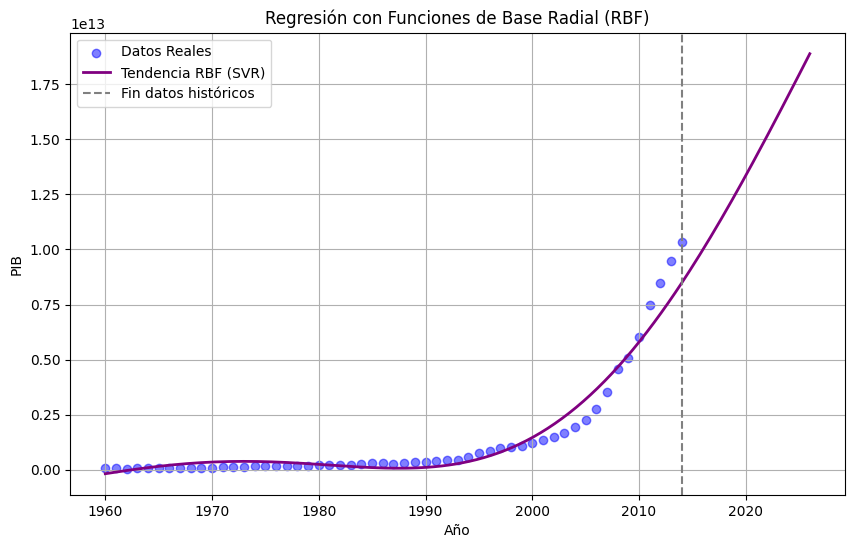

In [59]:
# División de datos escalados
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

# Ajustar el modelo SVR con kernel RBF
# C: Penalización por error, gamma: define el alcance de la influencia de un solo punto
modelo_rbf = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
modelo_rbf.fit(X_train, y_train)

# Visualización del ajuste
X_plot = np.linspace(X.min(), 2026, 200).reshape(-1, 1)
X_plot_scaled = scaler_X.transform(X_plot)
y_plot_scaled = modelo_rbf.predict(X_plot_scaled)
y_plot = scaler_y.inverse_transform(y_plot_scaled.reshape(-1, 1))

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', alpha=0.5, label='Datos Reales')
plt.plot(X_plot, y_plot, color='purple', linewidth=2, label='Tendencia RBF (SVR)')
plt.axvline(x=2014, color='gray', linestyle='--', label='Fin datos históricos')
plt.title('Regresión con Funciones de Base Radial (RBF)')
plt.xlabel('Año')
plt.ylabel('PIB')
plt.legend()
plt.grid(True)
plt.show()

Tras entrenar el modelo, se realizan predicciones con los datos de prueba. Como los resultados salen en el formato escalado del bloque 1, aquí se realiza una operación inversa para convertir esos números nuevamente en billones de dólares, permitiendo así calcular qué tan cerca se estuvo del dato real.

In [60]:
# Predicción y des-escalamiento para métricas
y_pred_scaled = modelo_rbf.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))
y_test_orig = scaler_y.inverse_transform(y_test.reshape(-1, 1))

# Métricas
mae = mean_absolute_error(y_test_orig, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
r2 = r2_score(y_test_orig, y_pred)

print("--- Evaluación del Modelo RBF ---")
print(f"MAE:  {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²:   {r2:.4f}")

--- Evaluación del Modelo RBF ---
MAE:  368,210,701,309.41
RMSE: 520,394,854,748.71
R²:   0.9588


Se introducen los años 2025 y 2026 para observar cómo se comporta el modelo fuera de su zona conocida. Aqui se revela de gran manera el funcionamiento del algoritmo, ya que los modelos radiales suelen mantenerse en valores no tan alejados de las referencias cuando presentan mayor distancia de los datos históricos, tendiendo a estabilizarse en lugar de seguir creciendo infinitamente.

In [61]:
# Predicción para años futuros
anios_futuros = np.array([[2025], [2026]])
anios_futuros_scaled = scaler_X.transform(anios_futuros)
pred_futuras_scaled = modelo_rbf.predict(anios_futuros_scaled)
pred_futuras = scaler_y.inverse_transform(pred_futuras_scaled.reshape(-1, 1))

print("--- Predicciones RBF ---")
print(f"Predicción PIB 2025: {pred_futuras[0][0]:,.2f}")
print(f"Predicción PIB 2026: {pred_futuras[1][0]:,.2f}")

# Error porcentual 2025
pib_2025_real = 19.652 * 1e12
error_pct = abs(pred_futuras[0][0] - pib_2025_real) / pib_2025_real * 100
print(f"\nError Porcentual para 2025: {error_pct:.2f}%")

--- Predicciones RBF ---
Predicción PIB 2025: 17,950,456,910,756.86
Predicción PIB 2026: 18,896,096,215,214.23

Error Porcentual para 2025: 8.66%


    Conclusión

El modelo basado en funciones de base radial ha demostrado ser la herramienta más eficaz para este estudio, alcanzando un coeficiente de determinación $R^2$ de 0.9588. A diferencia de los métodos anteriores, la base de este algoritmo no intenta forzar una tendencia de crecimiento infinito, sino que basa sus predicciones en la proximidad de los datos históricos conocidos. Esta característica permitió obtener una proyección para el año 2025 de 17.95 billones de USD, situándose como la estimación más cercana al valor real de 19.65 billones. El error porcentual resultante de apenas el 8.66% valida la eficacia de este enfoque para obtener valores futuros de la economía china.A pesar de su alta precisión, la principal limitación del enfoque RBF radica en su naturaleza local y su dependencia del escalamiento de datos. Al alejarse de los registros históricos es decir en el periodo posterior al año 2014, el modelo pierde gradualmente su punto de referencia, lo que puede provocar que la curva de proyección se estabilice antes de lo esperado o ignore cambios estructurales abruptos que no tengan un antecedente similar en el pasado.

# Comparación entre los tres modelos y conclusión final

--- TABLA COMPARATIVA DE RENDIMIENTO ---
              Modelo  R² (Prueba) Predicción 2025 (Billones) Error % (2025)
Polinomial (Grado 3)       0.9679                     23.41T         19.12%
   Splines (Grado 1)       0.9776                     16.28T         17.13%
                 RBF       0.9588                     17.95T          8.66%


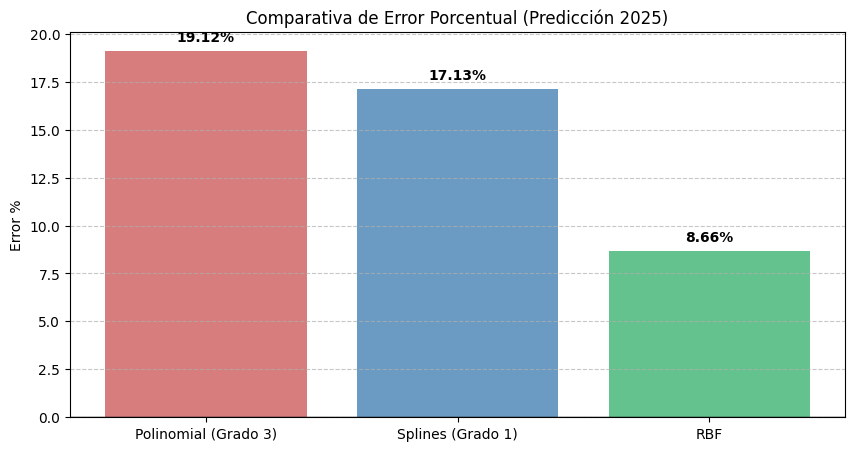

In [62]:
#Importación de librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Definición de los resultados obtenidos
modelos = ['Polinomial (Grado 3)', 'Splines (Grado 1)', 'RBF']
r2_scores = [0.9679, 0.9776, 0.9588]
errores_2025 = [19.12, 17.13, 8.66]
predicciones_2025 = [23.41e12, 16.28e12, 17.95e12] # Valores en billones
pib_real_2025 = 19.652e12

# Creación de la Tabla Comparativa
data = {
    'Modelo': modelos,
    'R² (Prueba)': r2_scores,
    'Predicción 2025 (Billones)': [f"{p/1e12:.2f}T" for p in predicciones_2025],
    'Error % (2025)': [f"{e:.2f}%" for e in errores_2025]
}

df_comparativo = pd.DataFrame(data)
print("--- TABLA COMPARATIVA DE RENDIMIENTO ---")
print(df_comparativo.to_string(index=False))

# Visualización Gráfica de Errores
plt.figure(figsize=(10, 5))
colors = ['indianred', 'steelblue', 'mediumseagreen']

plt.bar(modelos, errores_2025, color=colors, alpha=0.8)
plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
plt.title('Comparativa de Error Porcentual (Predicción 2025)')
plt.ylabel('Error %')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Añadir etiquetas de valor sobre las barras
for i, v in enumerate(errores_2025):
    plt.text(i, v + 0.5, f"{v}%", ha='center', fontweight='bold')

plt.show()

    Conclusión

El desarrollo de este ejercicio permite concluir que la elección de un modelo de aprendizaje automático debe basarse no solo en su precisión histórica ($R^2$), sino fundamentalmente en su capacidad para generalizar tendencias en escenarios de largo plazo. A lo largo del estudio, se observó que la Regresión Polinomial de Grado 3 tiende a una sobreestimación mayor de error del 19.12% debido a su sensibilidad ante la aceleración de datos pasados, mientras que la Regresión con Splines de Grado 1 ofreció una alternativa más estable con un error del 17.13% al fragmentar la serie temporal en segmentos lineales. Sin embargo, el modelo de Funciones de Base Radial (RBF) se consolidó como la herramienta más robusta, logrando un error porcentual de el 8.66%, lo que demuestra que un enfoque basado en la similitud y proximidad de los datos es más efectivo para obtener las prediccione de una economía en comparación con  las proyecciones geométricas.